### Now that we've gotten the chemical properties and added it to our data, let's now discover potential trends into answering the question:

**What chemical properties contribute to a higher pChEMBL value (drug potency/interactivity of TRPV1 recepter)**

In [ ]:
import pandas as pd

In [ ]:
# Let's get our training/testing data from step 0
analysis_trend_data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/TRPV1-drug-discovery-research/train_test_data/trpv1_agonist_data_trends.csv")
analysis_trend_data.head(5)

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
0,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.20,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
1,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.31,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
2,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,8.05,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
3,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.40,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
4,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.00,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0


### Recall that from step 3, we are determing if our data is either linear or non-linear to decide what feature selection method we should use.


- Mutual information
- Distance correlation
- HSIC
- Chi-Squared Test
- Random forest
- XGBoost

### Let's visualize these parameters with the pchembl_value as the target.
- alogp
- aromatic_rings
- full_mwt
- hba
- hbd
- heavy_atoms
- mw_freebase
- np_likeness_score
- num_ro5_violations
- psa
- qed_weighted
- rtb

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Set target axis
x = analysis_trend_data['pchembl_value']

# Set parameter axis
alogp = analysis_trend_data['alogp']
aromatic_rings = analysis_trend_data['aromatic_rings']
full_mwt = analysis_trend_data['full_mwt']
hba = analysis_trend_data['hba']
hbd = analysis_trend_data['hbd']
heavy_atoms = analysis_trend_data['heavy_atoms']
mw_freebase = analysis_trend_data['mw_freebase']
np_likeness_score = analysis_trend_data['np_likeness_score']
num_ro5_violations = analysis_trend_data['num_ro5_violations']
psa = analysis_trend_data['psa']
qed_weighted = analysis_trend_data['qed_weighted']
rtb = analysis_trend_data['rtb']

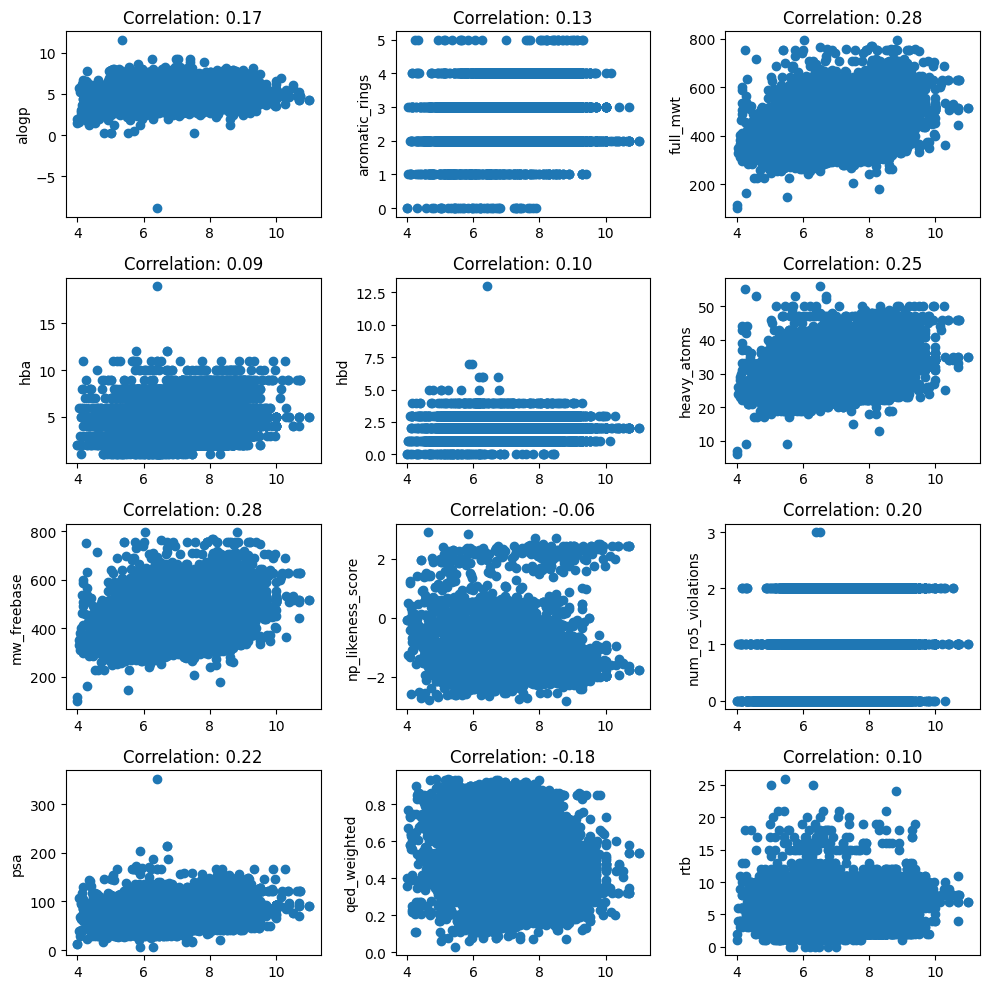

In [ ]:
# Correlation analysis value of all 12 attributes
alogp_df = analysis_trend_data.loc[:, ['pchembl_value', 'alogp']]
aromatic_rings_df = analysis_trend_data.loc[:, ['pchembl_value', 'aromatic_rings']]
full_mwt_df = analysis_trend_data.loc[:, ['pchembl_value', 'full_mwt']]
hba_df = analysis_trend_data.loc[:, ['pchembl_value', 'hba']]
hbd_df = analysis_trend_data.loc[:, ['pchembl_value', 'hbd']]
heavy_atoms_df = analysis_trend_data.loc[:, ['pchembl_value', 'heavy_atoms']]
mw_freebase_df = analysis_trend_data.loc[:, ['pchembl_value', 'mw_freebase']]
np_likeness_score_df = analysis_trend_data.loc[:, ['pchembl_value', 'np_likeness_score']]
num_ro5_violations_df = analysis_trend_data.loc[:, ['pchembl_value', 'num_ro5_violations']]
psa_df = analysis_trend_data.loc[:, ['pchembl_value', 'psa']]
qed_weighted_df = analysis_trend_data.loc[:, ['pchembl_value', 'qed_weighted']]
rtb_df = analysis_trend_data.loc[:, ['pchembl_value', 'rtb']]

fig, axs = plt.subplots(4, 3, figsize=(10, 10))

axs[0, 0].scatter(x, alogp)
axs[0, 0].set_title(f"Correlation: {alogp_df.corr().iloc[0, 1]:.2f}")
axs[0, 0].set_ylabel("alogp")

axs[0, 1].scatter(x, aromatic_rings)
axs[0, 1].set_title(f"Correlation: {aromatic_rings_df.corr().iloc[0, 1]:.2f}")
axs[0, 1].set_ylabel("aromatic_rings")

axs[0, 2].scatter(x, full_mwt)
axs[0, 2].set_title(f"Correlation: {full_mwt_df.corr().iloc[0, 1]:.2f}")
axs[0, 2].set_ylabel("full_mwt")

axs[1, 0].scatter(x, hba)
axs[1, 0].set_title(f"Correlation: {hba_df.corr().iloc[0, 1]:.2f}")
axs[1, 0].set_ylabel("hba")

axs[1, 1].scatter(x, hbd)
axs[1, 1].set_title(f"Correlation: {hbd_df.corr().iloc[0, 1]:.2f}")
axs[1, 1].set_ylabel("hbd")

axs[1, 2].scatter(x, heavy_atoms)
axs[1, 2].set_title(f"Correlation: {heavy_atoms_df.corr().iloc[0, 1]:.2f}")
axs[1, 2].set_ylabel("heavy_atoms")

axs[2, 0].scatter(x, mw_freebase)
axs[2, 0].set_title(f"Correlation: {mw_freebase_df.corr().iloc[0, 1]:.2f}")
axs[2, 0].set_ylabel("mw_freebase")

axs[2, 1].scatter(x, np_likeness_score)
axs[2, 1].set_title(f"Correlation: {np_likeness_score_df.corr().iloc[0, 1]:.2f}")
axs[2, 1].set_ylabel("np_likeness_score")

axs[2, 2].scatter(x, num_ro5_violations)
axs[2, 2].set_title(f"Correlation: {num_ro5_violations_df.corr().iloc[0, 1]:.2f}")
axs[2, 2].set_ylabel("num_ro5_violations")

axs[3, 0].scatter(x, psa)
axs[3, 0].set_title(f"Correlation: {psa_df.corr().iloc[0, 1]:.2f}")
axs[3, 0].set_ylabel("psa")

axs[3, 1].scatter(x, qed_weighted)
axs[3, 1].set_title(f"Correlation: {qed_weighted_df.corr().iloc[0, 1]:.2f}")
axs[3, 1].set_ylabel("qed_weighted")

axs[3, 2].scatter(x, rtb)
axs[3, 2].set_title(f"Correlation: {rtb_df.corr().iloc[0, 1]:.2f}")
axs[3, 2].set_ylabel("rtb")

fig.tight_layout()
plt.show()


### Well... it's quite obvious this data is non-linear

Let's use UMAP to figure out what attributes vary the most and potentially finding the factors that contribute to the potency/effectivity of a non-opioid a painkiller!

In [ ]:
import numpy as np

In [ ]:
# Let's first remove rows that contain empty values
analysis_trend_data = analysis_trend_data.dropna()
analysis_trend_data

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
0,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.20,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
1,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.31,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
2,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,8.05,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
3,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.40,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
4,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.00,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7943,CHEMBL39785,CCC(CCc1ccc(O)c(OC)c1)N(Cc1ccccc1)/C(S)=N/CCc1...,4.68,6.14,3.0,462.66,3.0,2.0,33.0,462.66,-0.14,1.0,45.06,0.20,11.0
7944,CHEMBL291285,COc1cc(CCC(CCc2ccccc2)O/C(S)=N/CCc2ccccc2)ccc1O,4.72,5.88,3.0,449.62,4.0,2.0,32.0,449.62,0.56,1.0,51.05,0.22,11.0
7945,CHEMBL36669,CCC(CCc1ccc(O)c(OC)c1)N(C)/C(S)=N/CCc1ccccc1,4.57,4.57,2.0,386.56,3.0,2.0,27.0,386.56,0.11,0.0,45.06,0.38,9.0
7946,CHEMBL440471,CCC(CCc1ccc(O)c(OC)c1)/N=C(\S)NCCc1ccccc1,4.54,4.23,2.0,372.53,3.0,3.0,26.0,372.53,0.08,0.0,53.85,0.35,9.0


# Random Forest approach - let's see what features play the biggest role in influencing pChEMBL values
https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

## First lets categorize our chemble values into three categories:
- Inactive (val < 5)
- Moderate (val >= 5 and val < 7)
- High (val >= 7)

### Let's first handle empty values NaN's and ensure each row is unique by ID

In [ ]:
conditions = [
    (analysis_trend_data['pchembl_value'] < 5),
    (analysis_trend_data['pchembl_value'] >= 5) & (analysis_trend_data['pchembl_value'] < 7),
    (analysis_trend_data['pchembl_value'] >= 7)
]
choices = ['Inactive', 'Moderate', 'High']

# Create the new 'Class_Select' column
analysis_trend_data['pchembl_value_class'] = np.select(conditions, choices, default='Unknown')
analysis_trend_data_classified = analysis_trend_data.drop(columns=['pchembl_value', 'canonical_smiles', 'molecule_chembl_id'])
analysis_trend_data_classified

,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb,pchembl_value_class
0,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,High
1,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,High
2,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,High
3,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,High
4,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7943,6.14,3.0,462.66,3.0,2.0,33.0,462.66,-0.14,1.0,45.06,0.20,11.0,Inactive
7944,5.88,3.0,449.62,4.0,2.0,32.0,449.62,0.56,1.0,51.05,0.22,11.0,Inactive
7945,4.57,2.0,386.56,3.0,2.0,27.0,386.56,0.11,0.0,45.06,0.38,9.0,Inactive
7946,4.23,2.0,372.53,3.0,3.0,26.0,372.53,0.08,0.0,53.85,0.35,9.0,Inactive


### In maching learning, X stands for features and y stands for labels/targets

In this case our target is `pchembl_value_class`

And the rest of our columns in `analysis_trend_data_classified` are the features

In [ ]:
X = analysis_trend_data_classified.drop(columns=['pchembl_value_class']).to_numpy()
y = analysis_trend_data_classified['pchembl_value_class'].to_numpy()
X, y


(array([[5.3700e+00, 4.0000e+00, 3.7744e+02, ..., 5.4880e+01, 5.2000e-01,
         3.0000e+00],
        [5.3700e+00, 4.0000e+00, 3.7744e+02, ..., 5.4880e+01, 5.2000e-01,
         3.0000e+00],
        [5.3700e+00, 4.0000e+00, 3.7744e+02, ..., 5.4880e+01, 5.2000e-01,
         3.0000e+00],
        ...,
        [4.5700e+00, 2.0000e+00, 3.8656e+02, ..., 4.5060e+01, 3.8000e-01,
         9.0000e+00],
        [4.2300e+00, 2.0000e+00, 3.7253e+02, ..., 5.3850e+01, 3.5000e-01,
         9.0000e+00],
        [4.2700e+00, 2.0000e+00, 3.5949e+02, ..., 5.1050e+01, 4.2000e-01,
         8.0000e+00]]),
 array(['High', 'High', 'High', ..., 'Inactive', 'Inactive', 'Moderate'],
       dtype=object))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

feature_names = analysis_trend_data_classified.drop(columns=['pchembl_value_class']).columns
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

### From here, we can determine feature importance using **Mean Decrease in Impurity (MDI)**

In [ ]:
import time

import numpy as np

start_time = time.time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.022 seconds


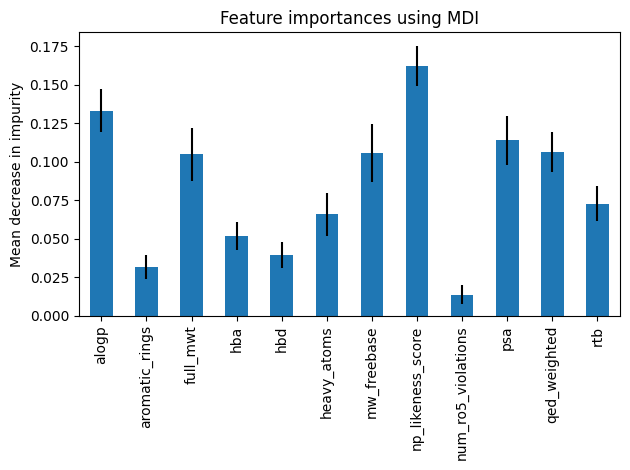

In [ ]:
import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [ ]:
from sklearn.inspection import permutation_importance

start_time = time.time()
result = permutation_importance(
    forest, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

Elapsed time to compute the importances: 7.719 seconds


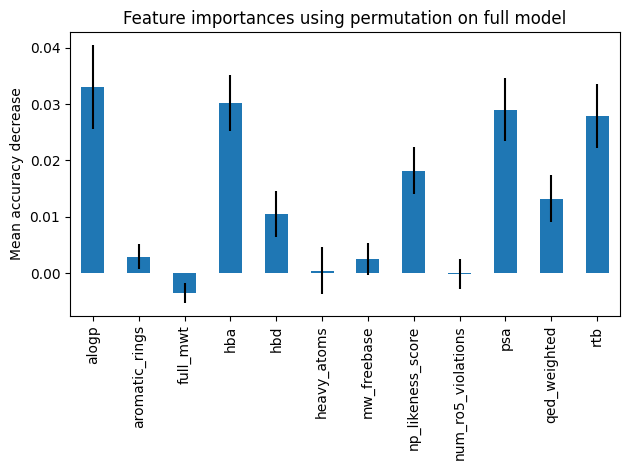

In [ ]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

### Using feature importance with permutations yields a clearer result. MDI is more difficult to determine importance because it is bias toards features that have more unique values. Permutations is not bias.

You can see that the top 5 ordered features that affect pChEMBL values are:
1. alogp (lipophilicity, how well the compound dissolves in fat)
2. hba (# of hydrogen bond acceptors)
3. psa (polar surface area)
4. rtb (# of rotatable bonds)
5. np_likeness_score (similarity of compound to its natural counterparts)


## Let's take a step back...

Are the top 5 chemical attributes calculated here, reasonable?

**This is something a scientist, specifically a chemist, can answer. What we can do for now, is compare the top and bottom 5 of compounds based on their pChEMBL values**

### Next, let refer back to steps 1 and 2 where we will build a new chemprop model but train it with the top 5 properties!!!

In [ ]:
ordered_analysis_trend_data = analysis_trend_data.sort_values(by='pchembl_value', ascending=False)
ordered_analysis_trend_data

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
2186,CHEMBL2177429,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)[C@@H](C)c2ccc...,11.00,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0
2190,CHEMBL2177429,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)[C@@H](C)c2ccc...,11.00,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0
12,CHEMBL17976,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@](Cc5ccccc5)(...,10.72,4.74,2.0,628.72,9.0,2.0,46.0,628.72,2.44,1.0,120.75,0.32,8.0
13,CHEMBL17976,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@](Cc5ccccc5)(...,10.72,4.74,2.0,628.72,9.0,2.0,46.0,628.72,2.44,1.0,120.75,0.32,8.0
2300,CHEMBL2177428,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)C(C)c2ccc(NS(C...,10.70,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5664,CHEMBL74415,CCCCCc1cc(O)c2c(c1)OC(C)(C)c1ccc(C)cc1-2,4.09,5.73,2.0,310.44,2.0,1.0,23.0,310.44,1.19,1.0,29.46,0.73,4.0
2421,CHEMBL2376852,CN(C)C(=O)n1nnc(Cc2ccc(-c3cccc(C(N)=O)c3)cc2)n1,4.04,1.56,3.0,350.38,6.0,1.0,26.0,350.38,-1.27,0.0,107.00,0.77,4.0
2734,CHEMBL3355287,CC(C)=CCC/C(C)=C/CNC(=O)Oc1ccc(C(C)(C)C)cc1,4.04,5.77,1.0,329.48,2.0,1.0,24.0,329.48,0.50,1.0,38.33,0.67,6.0
2984,CHEMBL2208211,CC(C)N=C=S,4.00,1.50,0.0,101.17,2.0,0.0,6.0,101.17,-0.06,0.0,12.36,0.36,1.0


In [ ]:
top_5 = ordered_analysis_trend_data.head(5)
top_5

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
2186,CHEMBL2177429,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)[C@@H](C)c2ccc...,11.00,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0
2190,CHEMBL2177429,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)[C@@H](C)c2ccc...,11.00,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0
12,CHEMBL17976,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@](Cc5ccccc5)(...,10.72,4.74,2.0,628.72,9.0,2.0,46.0,628.72,2.44,1.0,120.75,0.32,8.0
13,CHEMBL17976,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@](Cc5ccccc5)(...,10.72,4.74,2.0,628.72,9.0,2.0,46.0,628.72,2.44,1.0,120.75,0.32,8.0
2300,CHEMBL2177428,CC1CCN(c2nc(C(F)(F)F)ccc2CNC(=O)C(C)c2ccc(NS(C...,10.70,4.27,2.0,516.56,5.0,2.0,35.0,516.56,-1.77,1.0,91.40,0.54,7.0


In [ ]:
bot_5 = ordered_analysis_trend_data.tail(5)
bot_5

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
5664,CHEMBL74415,CCCCCc1cc(O)c2c(c1)OC(C)(C)c1ccc(C)cc1-2,4.09,5.73,2.0,310.44,2.0,1.0,23.0,310.44,1.19,1.0,29.46,0.73,4.0
2421,CHEMBL2376852,CN(C)C(=O)n1nnc(Cc2ccc(-c3cccc(C(N)=O)c3)cc2)n1,4.04,1.56,3.0,350.38,6.0,1.0,26.0,350.38,-1.27,0.0,107.00,0.77,4.0
2734,CHEMBL3355287,CC(C)=CCC/C(C)=C/CNC(=O)Oc1ccc(C(C)(C)C)cc1,4.04,5.77,1.0,329.48,2.0,1.0,24.0,329.48,0.50,1.0,38.33,0.67,6.0
2984,CHEMBL2208211,CC(C)N=C=S,4.00,1.50,0.0,101.17,2.0,0.0,6.0,101.17,-0.06,0.0,12.36,0.36,1.0
2985,CHEMBL3593576,CCC(C)N=C=S,4.00,1.89,0.0,115.20,2.0,0.0,7.0,115.20,-0.08,0.0,12.36,0.40,2.0


### Looking at these top and low 5's lets compare their averages

In [ ]:
top_5_mean = top_5.drop(columns=['canonical_smiles', 'molecule_chembl_id']).mean().to_frame("Top 5")
bot_5_mean = bot_5.drop(columns=['canonical_smiles', 'molecule_chembl_id']).mean().to_frame("Bottom 5")
compare_props = pd.concat([top_5_mean, bot_5_mean], axis=1)
compare_props["Difference"] = compare_props['Top 5'] - compare_props['Bottom 5']
compare_props.sort_values(by='Difference', ascending=False)

,Top 5,Bottom 5,Difference
full_mwt,561.424,241.334,320.090
mw_freebase,561.424,241.334,320.090
psa,103.140,39.902,63.238
heavy_atoms,39.400,17.200,22.200
pchembl_value,10.828,4.034,6.794
rtb,7.400,3.400,4.000
hba,6.600,2.800,3.800
hbd,2.000,0.600,1.400
alogp,4.458,3.290,1.168
aromatic_rings,2.000,1.200,0.800


### Recall the top 5 properties we found through random forest:
1. alogp (lipophilicity, how well the compound dissolves in fat)
2. hba (# of hydrogen bond acceptors)
3. psa (polar surface area)
4. rtb (# of rotatable bonds)
5. np_likeness_score (similarity of compound to its natural counterparts)